# Project Overview: Mental Health
**Objective:** To develop a robust machine learning model for identifying potential indicators of depression among individuals, utilizing behavioral metrics such as sleep duration and work-study intensity to optimize predictive performance and support early intervention strategies.

## 1. Libraries & Workspace Setup

In [1]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('playground-series-s4e11')

print("Path to competition files:", path)

Path to competition files: /kaggle/input/competitions/playground-series-s4e11


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import joblib
import pickle

## 2. Data Acquisition & Initial Inspection

### 2.1. Loading Train and Test Datasets

In [3]:
train_df=pd.read_csv('/kaggle/input/competitions/playground-series-s4e11/train.csv')
test_df=pd.read_csv('/kaggle/input/competitions/playground-series-s4e11/test.csv')

In [4]:
train_df.head()

,id,Name,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,0,Aaradhya,Female,49.0,Ludhiana,Working Professional,Chef,NaN,5.0,NaN,NaN,2.0,More than 8 hours,Healthy,BHM,No,1.0,2.0,No,0
1,1,Vivan,Male,26.0,Varanasi,Working Professional,Teacher,NaN,4.0,NaN,NaN,3.0,Less than 5 hours,Unhealthy,LLB,Yes,7.0,3.0,No,1
2,2,Yuvraj,Male,33.0,Visakhapatnam,Student,NaN,5.0,NaN,8.97,2.0,NaN,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
3,3,Yuvraj,Male,22.0,Mumbai,Working Professional,Teacher,NaN,5.0,NaN,NaN,1.0,Less than 5 hours,Moderate,BBA,Yes,10.0,1.0,Yes,1
4,4,Rhea,Female,30.0,Kanpur,Working Professional,Business Analyst,NaN,1.0,NaN,NaN,1.0,5-6 hours,Unhealthy,BBA,Yes,9.0,4.0,Yes,0


In [5]:
test_df.head()

,id,Name,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness
0,140700,Shivam,Male,53.0,Visakhapatnam,Working Professional,Judge,NaN,2.0,NaN,NaN,5.0,Less than 5 hours,Moderate,LLB,No,9.0,3.0,Yes
1,140701,Sanya,Female,58.0,Kolkata,Working Professional,Educational Consultant,NaN,2.0,NaN,NaN,4.0,Less than 5 hours,Moderate,B.Ed,No,6.0,4.0,No
2,140702,Yash,Male,53.0,Jaipur,Working Professional,Teacher,NaN,4.0,NaN,NaN,1.0,7-8 hours,Moderate,B.Arch,Yes,12.0,4.0,No
3,140703,Nalini,Female,23.0,Rajkot,Student,NaN,5.0,NaN,6.84,1.0,NaN,More than 8 hours,Moderate,BSc,Yes,10.0,4.0,No
4,140704,Shaurya,Male,47.0,Kalyan,Working Professional,Teacher,NaN,5.0,NaN,NaN,5.0,7-8 hours,Moderate,BCA,Yes,3.0,4.0,No


### 2.2. Checking Structural Metadata

In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140700 entries, 0 to 140699
Data columns (total 20 columns):
 #   Column                                 Non-Null Count   Dtype  
---  ------                                 --------------   -----  
 0   id                                     140700 non-null  int64  
 1   Name                                   140700 non-null  object 
 2   Gender                                 140700 non-null  object 
 3   Age                                    140700 non-null  float64
 4   City                                   140700 non-null  object 
 5   Working Professional or Student        140700 non-null  object 
 6   Profession                             104070 non-null  object 
 7   Academic Pressure                      27897 non-null   float64
 8   Work Pressure                          112782 non-null  float64
 9   CGPA                                   27898 non-null   float64
 10  Study Satisfaction                     27897 non-null   

In [7]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93800 entries, 0 to 93799
Data columns (total 19 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     93800 non-null  int64  
 1   Name                                   93800 non-null  object 
 2   Gender                                 93800 non-null  object 
 3   Age                                    93800 non-null  float64
 4   City                                   93800 non-null  object 
 5   Working Professional or Student        93800 non-null  object 
 6   Profession                             69168 non-null  object 
 7   Academic Pressure                      18767 non-null  float64
 8   Work Pressure                          75022 non-null  float64
 9   CGPA                                   18766 non-null  float64
 10  Study Satisfaction                     18767 non-null  float64
 11  Jo

In [8]:
train_df.isnull().sum()

id                                            0
Name                                          0
Gender                                        0
Age                                           0
City                                          0
Working Professional or Student               0
Profession                                36630
Academic Pressure                        112803
Work Pressure                             27918
CGPA                                     112802
Study Satisfaction                       112803
Job Satisfaction                          27910
Sleep Duration                                0
Dietary Habits                                4
Degree                                        2
Have you ever had suicidal thoughts ?         0
Work/Study Hours                              0
Financial Stress                              4
Family History of Mental Illness              0
Depression                                    0
dtype: int64

In [9]:
test_df.isnull().sum()

id                                           0
Name                                         0
Gender                                       0
Age                                          0
City                                         0
Working Professional or Student              0
Profession                               24632
Academic Pressure                        75033
Work Pressure                            18778
CGPA                                     75034
Study Satisfaction                       75033
Job Satisfaction                         18774
Sleep Duration                               0
Dietary Habits                               5
Degree                                       2
Have you ever had suicidal thoughts ?        0
Work/Study Hours                             0
Financial Stress                             0
Family History of Mental Illness             0
dtype: int64

## 3. Exploratory Data Analysis

In [10]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,140700.0,70349.500000,40616.735775,0.00,35174.75,70349.50,105524.25,140699.0
Age,140700.0,40.388621,12.384099,18.00,29.00,42.00,51.00,60.0
Academic Pressure,27897.0,3.142273,1.380457,1.00,2.00,3.00,4.00,5.0
Work Pressure,112782.0,2.998998,1.405771,1.00,2.00,3.00,4.00,5.0
CGPA,27898.0,7.658636,1.464466,5.03,6.29,7.77,8.92,10.0
Study Satisfaction,27897.0,2.944940,1.360197,1.00,2.00,3.00,4.00,5.0
Job Satisfaction,112790.0,2.974404,1.416078,1.00,2.00,3.00,4.00,5.0
Work/Study Hours,140700.0,6.252679,3.853615,0.00,3.00,6.00,10.00,12.0
Financial Stress,140696.0,2.988983,1.413633,1.00,2.00,3.00,4.00,5.0
Depression,140700.0,0.181713,0.385609,0.00,0.00,0.00,0.00,1.0


In [11]:
test_df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,93800.0,187599.500000,27077.871962,140700.00,164149.75,187599.5,211049.25,234499.0
Age,93800.0,40.321685,12.393480,18.00,29.00,42.0,51.00,60.0
Academic Pressure,18767.0,3.158576,1.386666,1.00,2.00,3.0,4.00,5.0
Work Pressure,75022.0,3.011797,1.403563,1.00,2.00,3.0,4.00,5.0
CGPA,18766.0,7.674016,1.465056,5.03,6.33,7.8,8.94,10.0
Study Satisfaction,18767.0,2.939522,1.374242,1.00,2.00,3.0,4.00,5.0
Job Satisfaction,75026.0,2.960920,1.410710,1.00,2.00,3.0,4.00,5.0
Work/Study Hours,93800.0,6.247335,3.858191,0.00,3.00,6.0,10.00,12.0
Financial Stress,93800.0,2.978763,1.414604,1.00,2.00,3.0,4.00,5.0


/tmp/ipykernel_57/3724323730.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x='Depression', palette='viridis', edgecolor='black')


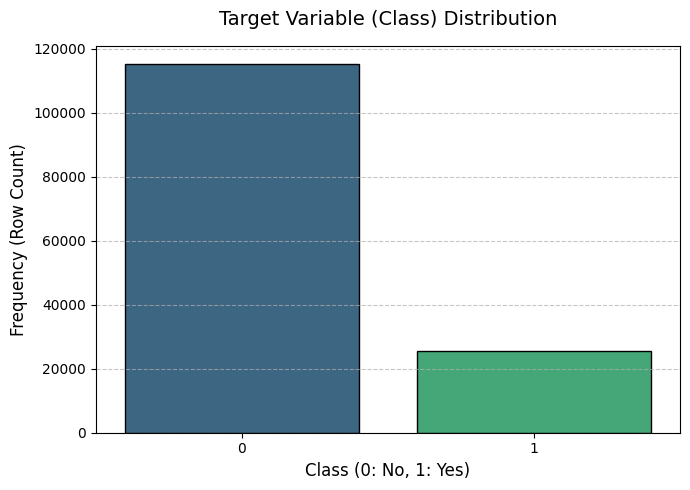

In [12]:
plt.figure(figsize=(7, 5))

sns.countplot(data=train_df, x='Depression', palette='viridis', edgecolor='black')

plt.title('Target Variable (Class) Distribution', fontsize=14, pad=15)
plt.xlabel('Class (0: No, 1: Yes)', fontsize=12)
plt.ylabel('Frequency (Row Count)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7) 

plt.tight_layout()
plt.show()

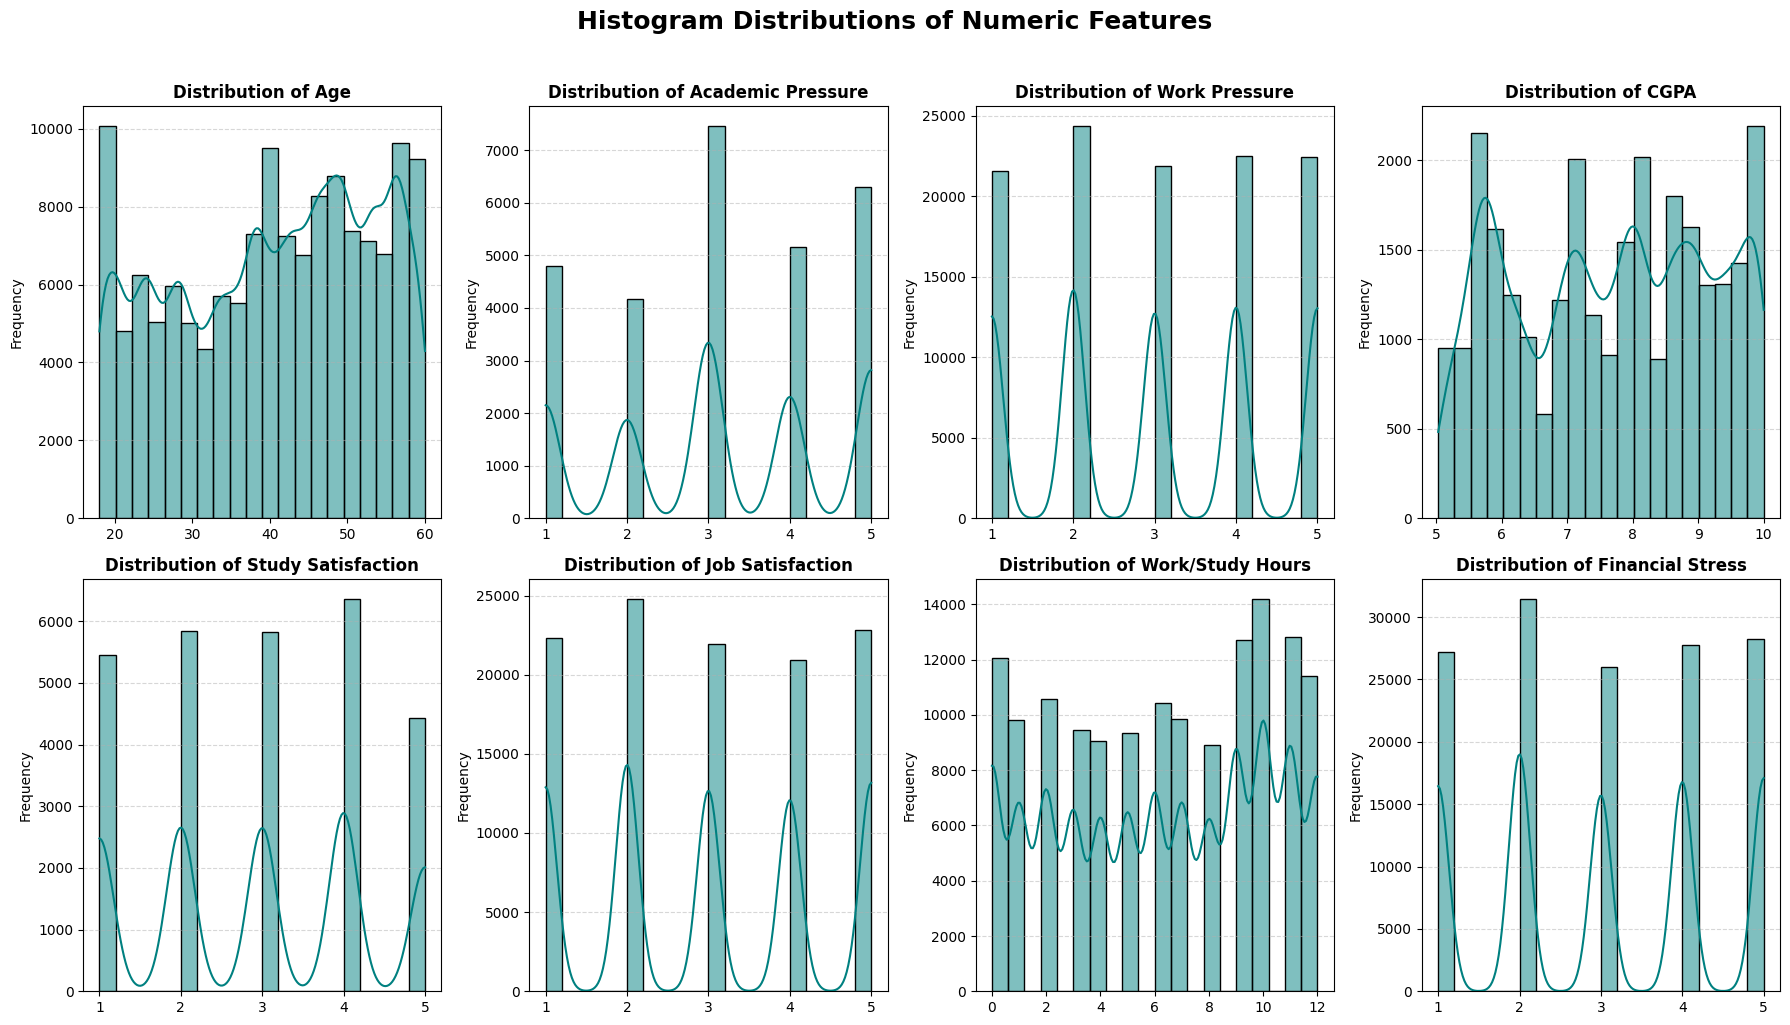

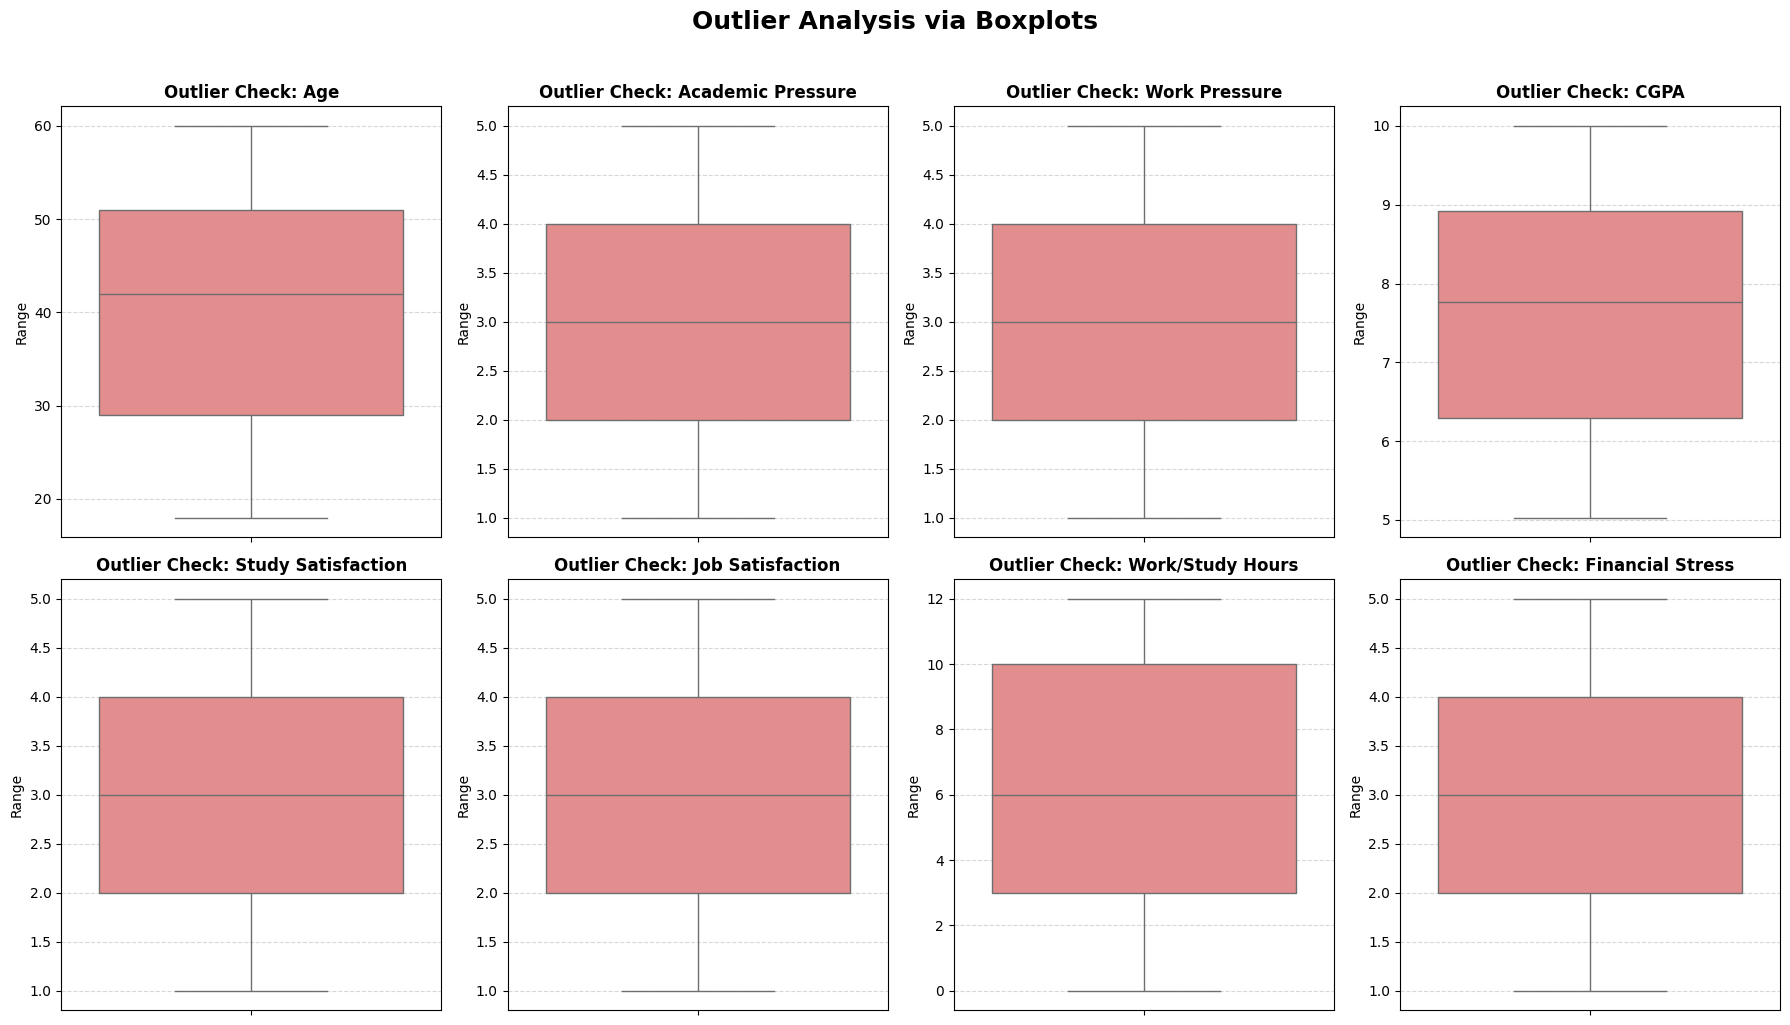

In [13]:
num_features = [
    'Age', 'Academic Pressure', 'Work Pressure', 'CGPA', 
    'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours', 'Financial Stress'
]

# Histogram
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.histplot(train_df[col].dropna(), kde=True, ax=axes[i], color='teal', bins=20)
    axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

for i in range(len(num_features), len(axes)):
    axes[i].axis('off')

plt.suptitle('Histogram Distributions of Numeric Features', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Boxplot
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.boxplot(y=train_df[col].dropna(), ax=axes[i], color='lightcoral')
    axes[i].set_title(f'Outlier Check: {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Range')
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)


for i in range(len(num_features), len(axes)):
    axes[i].axis('off')

plt.suptitle('Outlier Analysis via Boxplots', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [14]:
df_nulls = train_df.isnull()

df_nulls['Group'] = train_df['Working Professional or Student']
missing_data_summary = df_nulls.groupby('Group').sum()
missing_data_summary = missing_data_summary.loc[:, missing_data_summary.sum() > 0]

print(missing_data_summary)

                      Profession  Academic Pressure  Work Pressure    CGPA  \
Group                                                                        
Student                    27867                  9          27898       9   
Working Professional        8763             112794             20  112793   

                      Study Satisfaction  Job Satisfaction  Dietary Habits  \
Group                                                                        
Student                               10             27893               2   
Working Professional              112793                17               2   

                      Degree  Financial Stress  
Group                                           
Student                    0                 3  
Working Professional       2                 1  


## 4. Feature Engineering (FE) & Data Preprocessing

In [15]:
train_df['Pressure_Level'] = train_df['Academic Pressure']
train_df['Pressure_Level'] = train_df['Pressure_Level'].fillna(train_df['Work Pressure'])

test_df['Pressure_Level'] = test_df['Academic Pressure']
test_df['Pressure_Level'] = test_df['Pressure_Level'].fillna(test_df['Work Pressure'])

In [16]:
train_df['Pressure_Level'].isnull().sum()

np.int64(21)

In [17]:
test_df['Pressure_Level'].isnull().sum()

np.int64(12)

In [18]:
median_pressure = train_df['Pressure_Level'].median()

train_df['Pressure_Level'] = train_df['Pressure_Level'].fillna(median_pressure)
test_df['Pressure_Level'] = test_df['Pressure_Level'].fillna(median_pressure)

In [19]:
train_df = train_df.drop(columns=['Academic Pressure', 'Work Pressure'])
test_df = test_df.drop(columns=['Academic Pressure', 'Work Pressure'])

In [20]:
train_df['Satisfaction_Level'] = train_df['Study Satisfaction']
train_df['Satisfaction_Level'] = train_df['Satisfaction_Level'].fillna(train_df['Job Satisfaction'])

test_df['Satisfaction_Level'] = test_df['Study Satisfaction']
test_df['Satisfaction_Level'] = test_df['Satisfaction_Level'].fillna(test_df['Job Satisfaction'])


In [21]:
train_df['Satisfaction_Level'].isnull().sum()

np.int64(15)

In [22]:
test_df['Satisfaction_Level'].isnull().sum()

np.int64(8)

In [23]:
median_sat = train_df['Satisfaction_Level'].median()

train_df['Satisfaction_Level'] = train_df['Satisfaction_Level'].fillna(median_sat)
test_df['Satisfaction_Level'] = test_df['Satisfaction_Level'].fillna(median_sat)

In [24]:
train_df = train_df.drop(columns=['Study Satisfaction', 'Job Satisfaction'])
test_df = test_df.drop(columns=['Study Satisfaction', 'Job Satisfaction'])

In [25]:
null_cgpa_rows = train_df[train_df['CGPA'].isnull()]

In [26]:
cgpa_missing_by_group = null_cgpa_rows['Working Professional or Student'].value_counts()

In [27]:
cgpa_missing_by_group

Working Professional or Student
Working Professional    112793
Student                      9
Name: count, dtype: int64

In [28]:
train_df['CGPA'] = train_df['CGPA'].fillna(-1)
test_df['CGPA'] = test_df['CGPA'].fillna(-1)

In [29]:
null_profession_rows = train_df[train_df['Profession'].isnull()]
profession_missing_by_group = null_profession_rows['Working Professional or Student'].value_counts()

In [30]:
profession_missing_by_group

Working Professional or Student
Student                 27867
Working Professional     8763
Name: count, dtype: int64

In [31]:
train_df['Profession'] = train_df['Profession'].fillna('Student')
test_df['Profession'] = test_df['Profession'].fillna('Student')

In [32]:
for col in ['Dietary Habits', 'Degree', 'Financial Stress']:
    fill_value = train_df[col].mode()[0]
    
    train_df[col] = train_df[col].fillna(fill_value)
    test_df[col] = test_df[col].fillna(fill_value)

In [33]:
train_df['Sleep Duration'].value_counts(dropna=False)

Sleep Duration
Less than 5 hours    38784
7-8 hours            36969
More than 8 hours    32726
5-6 hours            32142
3-4 hours               12
6-7 hours                8
4-5 hours                7
4-6 hours                5
2-3 hours                5
6-8 hours                4
No                       4
1-6 hours                4
10-11 hours              2
9-11 hours               2
8-9 hours                2
Sleep_Duration           2
Unhealthy                2
45                       2
40-45 hours              1
1-2 hours                1
1-3 hours                1
9-6 hours                1
55-66 hours              1
Moderate                 1
35-36 hours              1
8 hours                  1
10-6 hours               1
Indore                   1
than 5 hours             1
49 hours                 1
Work_Study_Hours         1
3-6 hours                1
45-48 hours              1
9-5                      1
Pune                     1
9-5 hours                1
Name: count, 

In [34]:
train_df['Sleep Duration'].value_counts(dropna=False)

Sleep Duration
Less than 5 hours    38784
7-8 hours            36969
More than 8 hours    32726
5-6 hours            32142
3-4 hours               12
6-7 hours                8
4-5 hours                7
4-6 hours                5
2-3 hours                5
6-8 hours                4
No                       4
1-6 hours                4
10-11 hours              2
9-11 hours               2
8-9 hours                2
Sleep_Duration           2
Unhealthy                2
45                       2
40-45 hours              1
1-2 hours                1
1-3 hours                1
9-6 hours                1
55-66 hours              1
Moderate                 1
35-36 hours              1
8 hours                  1
10-6 hours               1
Indore                   1
than 5 hours             1
49 hours                 1
Work_Study_Hours         1
3-6 hours                1
45-48 hours              1
9-5                      1
Pune                     1
9-5 hours                1
Name: count, 

In [35]:
sleep_map = {
    'Less than 5 hours': 0, 
    '5-6 hours': 1, 
    '7-8 hours': 2, 
    'More than 8 hours': 3
}

In [36]:
train_df['Sleep Duration'] = train_df['Sleep Duration'].map(sleep_map)
test_df['Sleep Duration'] = test_df['Sleep Duration'].map(sleep_map)

In [37]:
train_df['Sleep Duration'].value_counts(dropna=False)

Sleep Duration
0.0    38784
2.0    36969
3.0    32726
1.0    32142
NaN       79
Name: count, dtype: int64

In [38]:
test_df['Sleep Duration'].value_counts(dropna=False)

Sleep Duration
0.0    25661
2.0    24491
3.0    22190
1.0    21404
NaN       54
Name: count, dtype: int64

In [39]:
mode_val = train_df['Sleep Duration'].mode()[0]
train_df['Sleep Duration'] = train_df['Sleep Duration'].fillna(mode_val)
test_df['Sleep Duration'] = test_df['Sleep Duration'].fillna(mode_val)

In [40]:
binary_cols = ['Have you ever had suicidal thoughts ?', 'Family History of Mental Illness']
for col in binary_cols:
    train_df[col] = train_df[col].map({'Yes': 1, 'No': 0})
    test_df[col] = test_df[col].map({'Yes': 1, 'No': 0})

In [41]:
categorical_cols = ['Gender', 'City', 'Working Professional or Student', 'Profession', 'Degree', 'Dietary Habits']
full_df = pd.concat([train_df, test_df], axis=0)
full_df = pd.get_dummies(full_df, columns=categorical_cols, drop_first=True)

In [42]:
train_df = full_df.iloc[:len(train_df)]
test_df = full_df.iloc[len(train_df):]

In [43]:
bool_cols_train = train_df.select_dtypes(include=['bool']).columns
train_df[bool_cols_train] = train_df[bool_cols_train].astype(int)

bool_cols_test = test_df.select_dtypes(include=['bool']).columns
test_df[bool_cols_test] = test_df[bool_cols_test].astype(int)


/tmp/ipykernel_57/3014443649.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df[bool_cols_train] = train_df[bool_cols_train].astype(int)
/tmp/ipykernel_57/3014443649.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df[bool_cols_test] = test_df[bool_cols_test].astype(int)


In [44]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 140700 entries, 0 to 140699
Columns: 407 entries, id to Dietary Habits_Yes
dtypes: float64(8), int64(398), object(1)
memory usage: 438.0+ MB


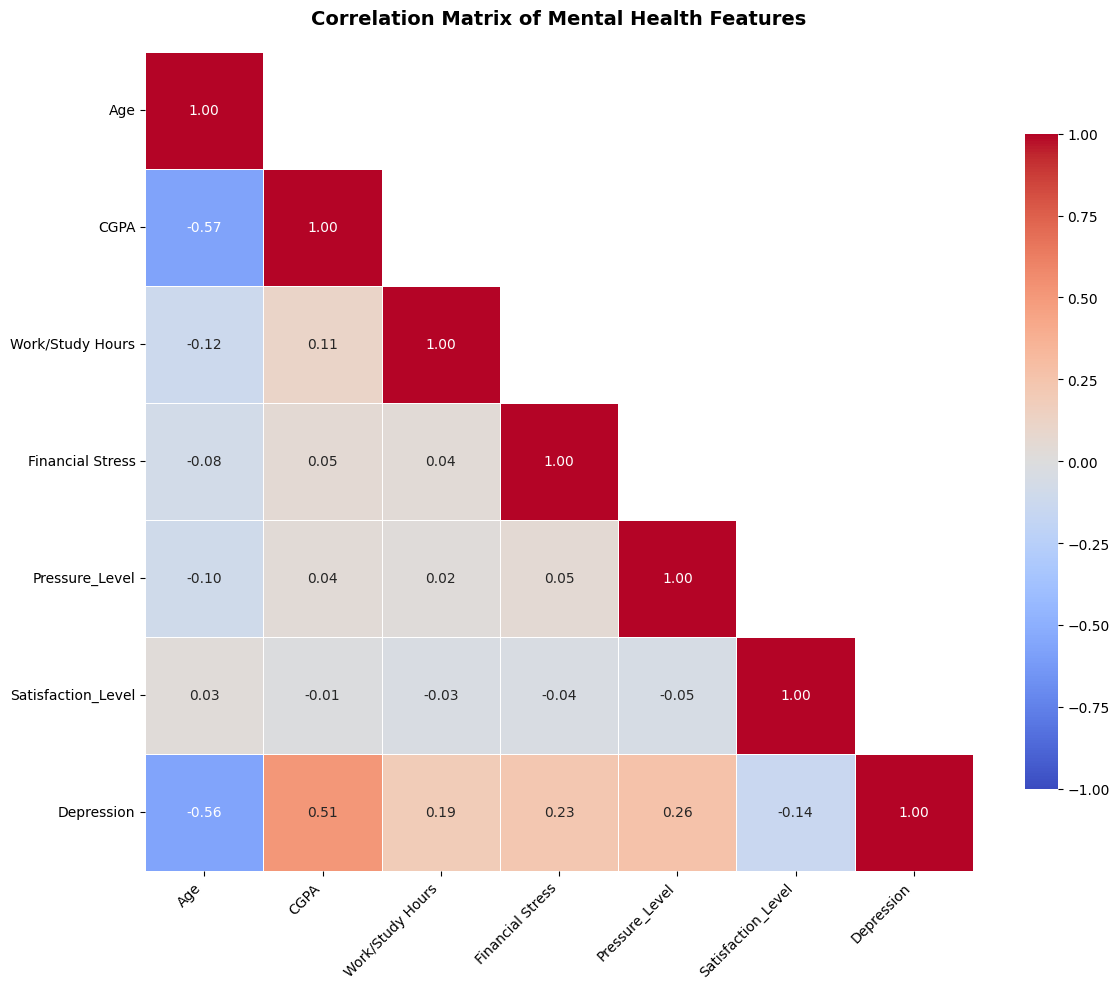

In [45]:
all_relevant_features = [
    'Age', 'CGPA', 'Work/Study Hours', 'Financial Stress', 
    'Pressure_Level', 'Satisfaction_Level', 'Depression'
]

corr_matrix = train_df[all_relevant_features].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix, 
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    annot_kws={"size": 10}
)

plt.title('Correlation Matrix of Mental Health Features', fontsize=14, weight='bold', pad=20)
plt.xticks(rotation=45, ha='right') 
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [46]:
x = train_df.drop(columns=['Depression', 'id', 'Name'], errors='ignore')
y = train_df['Depression']

In [47]:
x.shape

(140700, 404)

In [48]:
x

,Age,CGPA,Sleep Duration,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Pressure_Level,Satisfaction_Level,Gender_Male,...,Dietary Habits_No Healthy,Dietary Habits_Prachi,Dietary Habits_Pratham,Dietary Habits_Raghav,Dietary Habits_Resistant,Dietary Habits_Soham,Dietary Habits_Unhealthy,Dietary Habits_Vegas,Dietary Habits_Vivaan,Dietary Habits_Yes
0,49.0,-1.00,3.0,0,1.0,2.0,0,5.0,2.0,0,...,0,0,0,0,0,0,0,0,0,0
1,26.0,-1.00,0.0,1,7.0,3.0,0,4.0,3.0,1,...,0,0,0,0,0,0,1,0,0,0
2,33.0,8.97,1.0,1,3.0,1.0,0,5.0,2.0,1,...,0,0,0,0,0,0,0,0,0,0
3,22.0,-1.00,0.0,1,10.0,1.0,1,5.0,1.0,1,...,0,0,0,0,0,0,0,0,0,0
4,30.0,-1.00,1.0,1,9.0,4.0,1,1.0,1.0,0,...,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140695,18.0,-1.00,1.0,0,2.0,4.0,1,5.0,4.0,0,...,0,0,0,0,0,0,1,0,0,0
140696,41.0,-1.00,2.0,1,6.0,5.0,1,5.0,4.0,0,...,0,0,0,0,0,0,0,0,0,0
140697,24.0,-1.00,3.0,0,4.0,4.0,0,3.0,1.0,0,...,0,0,0,0,0,0,0,0,0,0
140698,49.0,-1.00,1.0,1,10.0,1.0,0,5.0,2.0,0,...,0,0,0,0,0,0,0,0,0,0


In [49]:
y.shape

(140700,)

In [50]:
x_test_final = test_df.drop(columns=['id', 'Name', 'Depression'], errors='ignore')

In [51]:
x_test_final

,Age,CGPA,Sleep Duration,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Pressure_Level,Satisfaction_Level,Gender_Male,...,Dietary Habits_No Healthy,Dietary Habits_Prachi,Dietary Habits_Pratham,Dietary Habits_Raghav,Dietary Habits_Resistant,Dietary Habits_Soham,Dietary Habits_Unhealthy,Dietary Habits_Vegas,Dietary Habits_Vivaan,Dietary Habits_Yes
0,53.0,-1.00,0.0,0,9.0,3.0,1,2.0,5.0,1,...,0,0,0,0,0,0,0,0,0,0
1,58.0,-1.00,0.0,0,6.0,4.0,0,2.0,4.0,0,...,0,0,0,0,0,0,0,0,0,0
2,53.0,-1.00,2.0,1,12.0,4.0,0,4.0,1.0,1,...,0,0,0,0,0,0,0,0,0,0
3,23.0,6.84,3.0,1,10.0,4.0,0,5.0,1.0,0,...,0,0,0,0,0,0,0,0,0,0
4,47.0,-1.00,2.0,1,3.0,4.0,0,5.0,5.0,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93795,49.0,-1.00,0.0,1,2.0,2.0,1,3.0,5.0,0,...,0,0,0,0,0,0,0,0,0,0
93796,29.0,-1.00,2.0,1,11.0,3.0,1,5.0,1.0,1,...,0,0,0,0,0,0,0,0,0,0
93797,24.0,7.51,2.0,0,7.0,1.0,0,1.0,4.0,1,...,0,0,0,0,0,0,0,0,0,0
93798,23.0,-1.00,1.0,1,7.0,5.0,1,4.0,2.0,0,...,0,0,0,0,0,0,0,0,0,0


In [52]:
x_test_final.shape

(93800, 404)

## 5. Model Training, Optimization & Deployment Strategy

In [53]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import BernoulliNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

def algo_test(x, y):
    b = BernoulliNB()
    l = LogisticRegression(max_iter=1000, class_weight='balanced', n_jobs=-1, random_state=42)
    d = DecisionTreeClassifier(max_depth=15, class_weight='balanced', random_state=42)
    r = RandomForestClassifier(n_estimators=100, max_samples=0.2, class_weight='balanced', n_jobs=-1, random_state=42)
    gb = GradientBoostingClassifier(n_estimators=50, random_state=42)
    kn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
    ab = AdaBoostClassifier(random_state=42)
    svc = LinearSVC(class_weight='balanced', max_iter=2000, random_state=42, dual="auto")
    xgb = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.05, eval_metric='logloss', random_state=42)
    lgb = LGBMClassifier(n_estimators=100, max_depth=5, learning_rate=0.05, class_weight='balanced', n_jobs=-1, random_state=42, verbose=-1)

    models = [b, l, d, r, gb, kn, ab, svc, xgb, lgb]
    model_names = [
        "BernoulliNB", "LogisticRegression", "DecisionTreeClassifier", 
        "RandomForestClassifier", "GradientBoostingClassifier", "KNeighborsClassifier",
        "AdaBoostClassifier", "LinearSVC", "XGBClassifier", "LGBMClassifier"
    ]

    x_train_split, x_val_split, y_train_split, y_val_split = train_test_split(
        x, y, test_size=0.20, random_state=42, stratify=y
    )
    
    scaler = StandardScaler()
    x_train_scaled = pd.DataFrame(scaler.fit_transform(x_train_split), columns=x_train_split.columns, index=x_train_split.index)
    x_val_scaled = pd.DataFrame(scaler.transform(x_val_split), columns=x_val_split.columns, index=x_val_split.index)
    
    accuracy, precision, recall, f1 = [], [], [], []
    successful_models = []
    successful_names = []

    for model, name in zip(models, model_names):
        print(f"--> Training {name}...")
        try:
            model_fitted = model.fit(x_train_scaled, y_train_split)
            prediction = model_fitted.predict(x_val_scaled)
            
            accuracy.append(accuracy_score(y_val_split, prediction))
            precision.append(precision_score(y_val_split, prediction, zero_division=0))
            recall.append(recall_score(y_val_split, prediction, zero_division=0))
            f1.append(f1_score(y_val_split, prediction, zero_division=0))
            
            successful_models.append(model_fitted)
            successful_names.append(name)
        except Exception as e:
            print(f" [!] Error executing pipeline for {name}: {e}")
            continue

    metrics = pd.DataFrame(index=successful_names)
    metrics["Accuracy"] = accuracy
    metrics["Precision"] = precision  
    metrics["Recall"] = recall
    metrics["F1"] = f1
    metrics["Model_Object"] = successful_models

    metrics.sort_values("F1", ascending=False, inplace=True)

    print("\n" + "="*50)
    best_model_name = metrics.index[0]
    print(f"TRUE MOST SUCCESSFUL MODEL BASED ON F1: {best_model_name}")
    print("="*50 + "\n")
    
    best_model_object = metrics.loc[best_model_name, "Model_Object"]
    final_prediction = best_model_object.predict(x_val_scaled)
    
    print(f"Real Confusion Matrix ({best_model_name}):")
    print(confusion_matrix(y_val_split, final_prediction))
    print(f"\nReal Classification Report ({best_model_name}):")
    print(classification_report(y_val_split, final_prediction))
    
    report_df = metrics.drop(columns=["Model_Object"])
    return report_df, metrics

In [54]:
report, full_metrics = algo_test(x, y)

--> Training BernoulliNB...
--> Training LogisticRegression...
--> Training DecisionTreeClassifier...
--> Training RandomForestClassifier...
--> Training GradientBoostingClassifier...
--> Training KNeighborsClassifier...
--> Training AdaBoostClassifier...
--> Training LinearSVC...
--> Training XGBClassifier...
--> Training LGBMClassifier...

TRUE MOST SUCCESSFUL MODEL BASED ON F1: XGBClassifier

Real Confusion Matrix (XGBClassifier):
[[22236   791]
 [  981  4132]]

Real Classification Report (XGBClassifier):
              precision    recall  f1-score   support

         0.0       0.96      0.97      0.96     23027
         1.0       0.84      0.81      0.82      5113

    accuracy                           0.94     28140
   macro avg       0.90      0.89      0.89     28140
weighted avg       0.94      0.94      0.94     28140



In [55]:
report

,Accuracy,Precision,Recall,F1
XGBClassifier,0.937029,0.839326,0.808136,0.823436
AdaBoostClassifier,0.934755,0.828423,0.808332,0.818254
GradientBoostingClassifier,0.935750,0.844774,0.791903,0.817484
RandomForestClassifier,0.931485,0.858590,0.745746,0.798200
LogisticRegression,0.914357,0.700074,0.924897,0.796933
LinearSVC,0.913539,0.696827,0.927831,0.795906
LGBMClassifier,0.913042,0.695569,0.927244,0.794870
DecisionTreeClassifier,0.907854,0.702507,0.854880,0.771240
KNeighborsClassifier,0.895167,0.740708,0.650890,0.692900
BernoulliNB,0.862260,0.595051,0.757285,0.666437


In [56]:
x_raw_train, x_raw_val, y_raw_train, y_raw_val = train_test_split(x, y, test_size=0.20, random_state=42, stratify=y)

In [57]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_raw_train)
x_val_scaled = scaler.transform(x_raw_val)

In [58]:
model = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.05, eval_metric='logloss', random_state=42)

In [59]:
model.fit(x_train_scaled, y_raw_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [60]:
y_pred = model.predict(x_val_scaled)
y_scores = model.predict_proba(x_val_scaled)[:, 1]

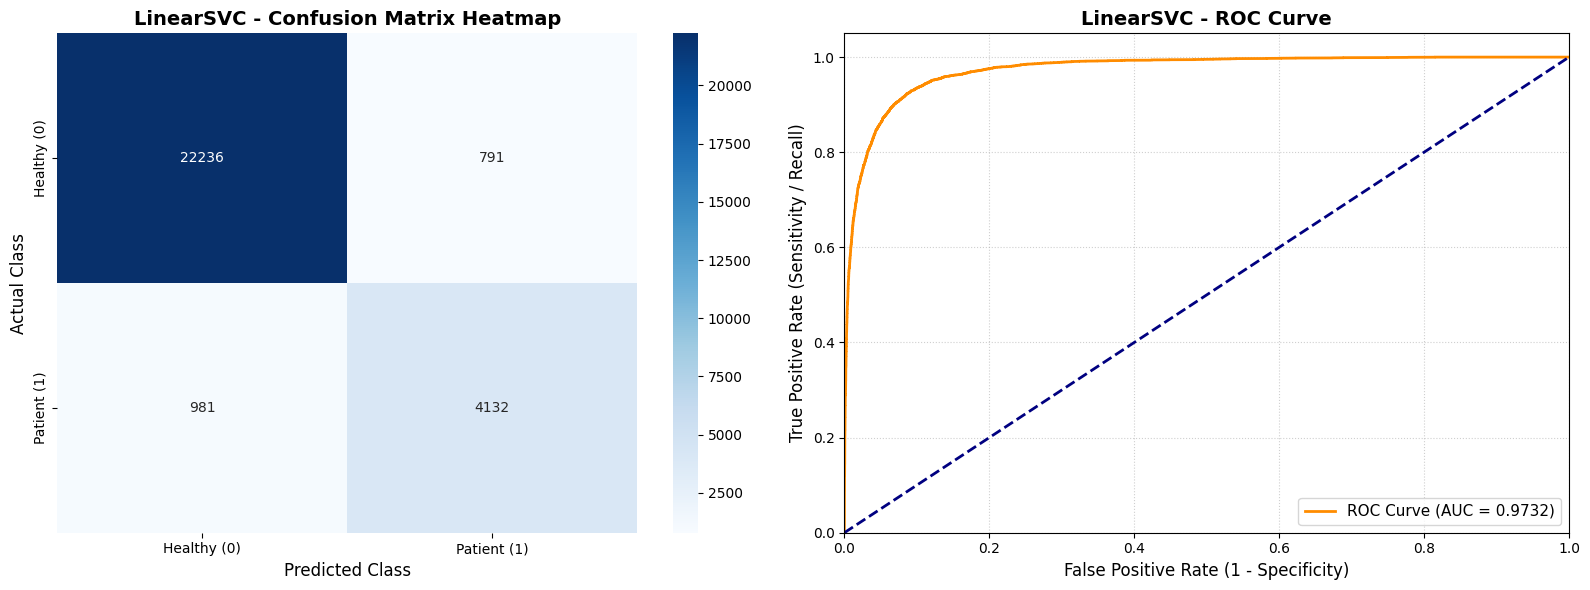

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm = confusion_matrix(y_raw_val, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Healthy (0)', 'Patient (1)'],
            yticklabels=['Healthy (0)', 'Patient (1)'])

axes[0].set_title('LinearSVC - Confusion Matrix Heatmap', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted Class', fontsize=12)
axes[0].set_ylabel('Actual Class', fontsize=12)


fpr, tpr, thresholds = roc_curve(y_raw_val, y_scores)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Rastgele tahmin çizgisi
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
axes[1].set_ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12)
axes[1].set_title('LinearSVC - ROC Curve', fontsize=14, fontweight='bold')
axes[1].legend(loc="lower right", fontsize=11)
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

In [62]:
final_scaler = StandardScaler()
x_final_train_scaled = final_scaler.fit_transform(x)
x_final_test_scaled = final_scaler.transform(x_test_final)

In [63]:
final_model = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.05, eval_metric='logloss', random_state=42)

In [64]:
final_model.fit(x_final_train_scaled, y)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [65]:
y_pred_final = final_model.predict(x_final_test_scaled)
y_proba_final = final_model.predict_proba(x_final_test_scaled)[:, 1]

In [66]:
submission = pd.DataFrame({
    'id': test_df['id'],
    'Depression': y_pred_final
})

submission.to_csv('final_predictions.csv', index=False)

In [67]:
joblib.dump(final_model, 'mental_healt_xgb.joblib')

['mental_healt_xgb.joblib']

In [68]:
with open('mental_healt_xgb.pkl', 'wb') as model_file:
    pickle.dump(final_model, model_file)

In [69]:
joblib.dump(final_scaler, 'final_scaler_mental.joblib')

['final_scaler_mental.joblib']

In [70]:
with open('final_scaler_mental.pkl', 'wb') as scaler_file:
    pickle.dump(final_scaler, scaler_file)

In [71]:
joblib.dump(x.columns, 'mental_trained_columns.pkl')

['mental_trained_columns.pkl']